In [1]:
import numpy
import scipy
from os.path import join
import matplotlib.pyplot as plt
import texplot
import matplotlib.ticker as mticker

# Imports from freealg
import freealg
from freealg import AlgebraicForm
from freealg.visualization import plot_flow, plot_mass, ridgeplot
from freealg.visualization._api_plot_util import _decimal_text, _k_pow2_formatter

# Plotting options
plot_dir = './plots'
save_filename = 'ntk_cifar_resnet50_fp64_n64K'
latex = True

# NTK CIFAR-10 ResNet50

In [6]:
config1 = dict(
    input_filename = 'ntk_cifar_resnet50_fp64_n64K_eigs.npz',
    # input_filename = 'ntk_cifar_resnet9_fp64_n64K_eigs.npz',
    deg_m = 3,
    effective_n = 80_000,
    xlim = (0, 0.8),
    ylim = (19, 19, 7),
    nbins = (80, 200),
    label_mode = 'pow-dec',
    save_filename = 'ntk_cifar10_resnet50_64K',
)

# -------

config = config1

Idx   Size
---  -----
0     1000
1     2000
2     4000
3     8000
4    16000
5    32000
6    64000



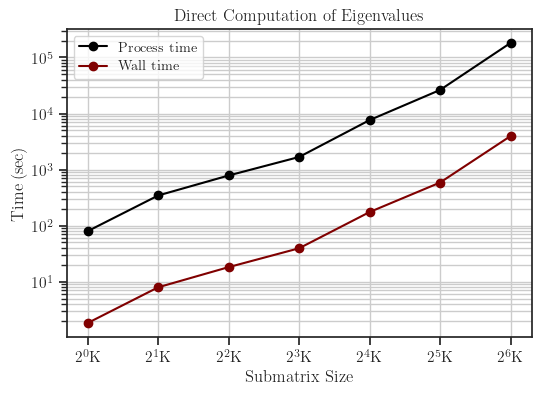

In [7]:
dir_ = '/home/sia/work/scripts/free/Xperimental/hessian'
data = numpy.load(join(dir_, config['input_filename']), allow_pickle=True)
out = data['out'].item()

sizes = out['sizes']
eigs = out['eigs']
wall_times = out['wall_times']
proc_times = out['proc_times']
n, p = out['shape']

# Sizes of submatrices
print('Idx   Size')
print('---  -----')
for i in range(sizes.size):
    print(f'{i:<2d}  {sizes[i]:>6d}')
print('')

# Plot wall and process times
with texplot.theme(use_latex=latex):
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(sizes, proc_times, '-o', color='black', label='Process time')
    ax.plot(sizes, wall_times, '-o', color='maroon', label='Wall time')
    ax.set_xlabel('Submatrix Size')
    ax.set_ylabel('Time (sec)')
    ax.set_title('Direct Computation of Eigenvalues')
    ax.legend(fontsize='small')
    ax.set_xscale('log', base=2)
    ax.xaxis.set_major_locator(mticker.LogLocator(base=2, subs=(1000/512.0,)))
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_k_pow2_formatter))
    ax.set_yscale('log')
    ax.grid(True, which='both')
    plt.show()

In [8]:
eigs_ravel = [None] * len(eigs)

for i in range(len(eigs)):
    eigs_ravel[i] = eigs[i].ravel()

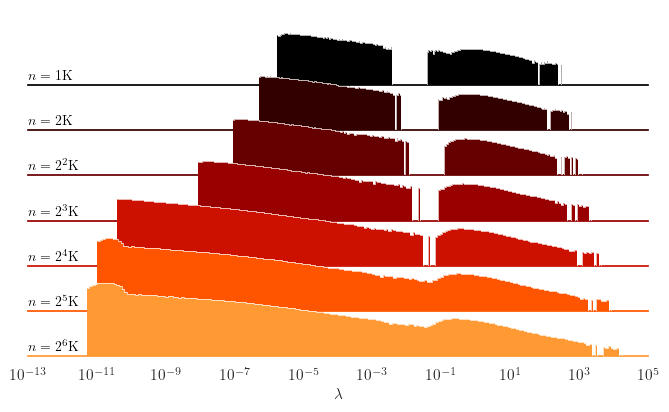

In [9]:
ridgeplot(sizes, eigs=eigs_ravel, log=True, scaley=False, hspace=-0.4,
          text_side='left', xlim=(1e-13, 1e5), figsize=(8, 4.5),
          label_mode='pow-int', latex=latex, save=False, nbins=200)

# Fit Spectral Curve

In [5]:
# Index to choose the initial sub-matrix size
# start_idx = 2  # TEST
start_idx = 2

# Detect support from histogram
support = freealg.supp(eigs[start_idx], method='hist', tol=0, nbins=150, log=True)
print('\n------------------------------------------')
print('Support (detected from histogram):')
for i, supp in enumerate(support):
    print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# Stieltjes options
stieltjes_opt = dict(
    n_levels = 200,
    max_subdivide = 4,
    anchor_mode = 'empirical',
    anchor_y_min = 1e-6,  # 1e-5~1e-6 cause left bulks to fail
    anchor_y_max = 10,
    anchor_ratio = 0.1,  # 0.1~1 cause stieltjes_emp to not latch to poly roots
)

# Smaller delta lowers the density baseline curve 1/x^2.
af = AlgebraicForm(eigs[start_idx],
                   support=support,
                   # support=None,
                   # delta=1e-5, # TEST
                   delta=1e-5,
                   log=True,
                   dtype='complex128',
                   stieltjes_opt=stieltjes_opt)

# We use deg_z = 1 since we guess the data is closely related to free Levy
# model, where deg_z is always 1. We also set _deg_m = 5 to have the capacity
# of representing 4 bulks once decompressed.
print('\n------------------------------------------')

# Combinations that work
# 8, 4
# 7, 3
deg_m, deg_z = 10, 10

coeffs = af.fit(
    deg_m, deg_z, reg=0,
    r=[1.8, 5],
    n_r=[1, 1],
    n_samples=4096,
    # y_eps=1e-5,
    y_eps=1e-4,
    # x_pad=0.0,
    normalize=True, triangular=None,
    # mu='auto',
    mu=None,
    mu_reg=None, verbose=True)

# print('\n------------------------------------------')
# print('Support (estimated from polynomial):')
# est_supp = af.support()
# for i, supp in enumerate(est_supp):
#     print(f'\tInterval {i+1}: ({supp[0]:>9.4f}, {supp[1]:>9.4f})')

# print('\n------------------------------------------')
# print('Atoms (estimated from polynomial):')
# for i, atom in enumerate(af.atoms()):
#     print(f'\tAtom {i+1}. x: {atom[0]:>4.1e}, '
#           f'weight: {100.0*atom[1]:>4.1f}%')


------------------------------------------
Support (detected from histogram):
	Interval 1: (   0.0000,    0.0024)
	Interval 2: (   0.0027,    0.0071)
	Interval 3: (   0.0097,    0.0113)
	Interval 4: (   0.1394,  223.6861)
	Interval 5: ( 306.2231,  919.2516)
	Interval 6: (1075.5582, 1258.4425)

------------------------------------------
fit residual max  : 3.5056e+05
fit residual 99.9%: 2.1820e+03

Coefficients (real)
+0.93693302 +94.69577694 +23.52519204 +3.61995499 -0.44012292 -0.19465281 -0.01738457 -0.00060292 -0.00000841 -0.00000004 +0.00000000 
-0.06279588 -6.36860312 -44.51985106 +2.51385067 +32.86825514 -2.81309080 -1.83763000 -0.17600613 -0.00636374 -0.00009248 -0.00000043 
+0.00027066 -0.05413533 -6.27027460 -59.18870113 -82.84465604 -13.64497742 -1.55469809 -0.06961996 -0.00158433 -0.00001856 -0.00000010 
-0.00000043 +0.00025626 +0.00931465 +0.05726744 -0.04847578 -0.00133342 +0.00013997 +0.00000890 +0.00000023 +0.00000000 +0.00000000 
+0.00000000 -0.00000042 -0.00001693 -0.

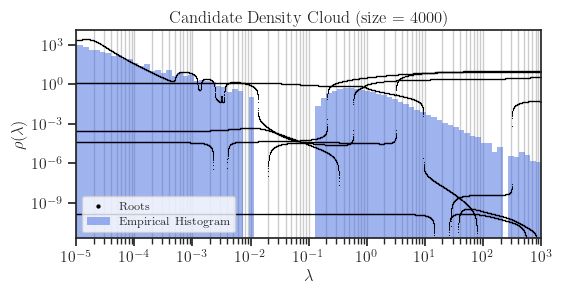

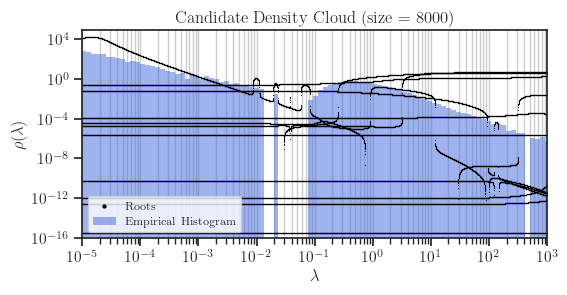

KeyboardInterrupt: 

In [6]:
# Check if the density plotted above is formed by correct roots. For this,
# we plot all possible roots below.
x_min = 1e-5
x_max = 1e3
x_highres = numpy.geomspace(x_min, x_max, 5000)

for idx in range(start_idx, sizes.size):
    af.candidates(
        size=sizes[idx],
        x=x_highres,
        eig=eigs[idx],
        delta=None, markersize=0.6, latex=latex)

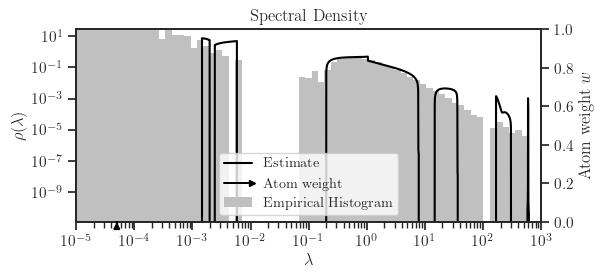


Mass: 1.01087449


In [8]:
# Plot density
x_min = 1e-6
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 5000)
rho0 = af.density(x, plot=True, latex=latex)

# Check mass (at start size)
print('')
mass = numpy.trapz(rho0, x)
print(f'Mass: {mass:0.8f}')

# Free Decompression

In [ ]:
# Choosing the largest sub-matrix size to decompress to
# end_idx = sizes.size - 1
end_idx = 6

# Subset of sizes to apply free decompression
fd_sizes = sizes[start_idx:end_idx+1]

# x span of decompression
x_min = 1e-11
x_max = 1e3
x = numpy.geomspace(x_min, x_max, 2000)

newton_opt = dict(
    dt_max=0.01,
    tol=1e-8,
    max_iter=1000,
    parallel=True,
    n_jobs=8,
    log_mode=True,
)

# Using method of characteristics (MoC) with 2x2 Newton and
# predictor/corrector (PC) to stabilize and speedup convergence
rho, x, atoms = af.decompress(
    fd_sizes, x=x, method='moc', min_n_times=10,
    newton_opt=newton_opt, return_atoms=True, atom_eps=0.0,
    verbose=False, plot=True, latex=latex)